<a href="https://www.kaggle.com/code/valeriislynko/yolo-training-exam?scriptVersionId=356531648" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Завдання 4: Встановлення офіційного пакета YOLO
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 578.7 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 4.4 MB/s eta 0:00:00


In [2]:
import os
import shutil
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [14]:
# 1. Завантажуємо базову модель YOLO11s (найлегша та найшвидша для навчання)
model = YOLO("yolo11s.pt")

In [15]:
# 2. Шлях до data.yaml у завантаженому датасеті
# Kaggle автоматично розпаковує датасет за цим шляхом:
DATA_YAML_PATH="/kaggle/input/uav-exam-dataset-fixed/data.yaml"

In [35]:
import os
print("Train exists:", os.path.exists('/kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/train/images'))
print("Valid exists:", os.path.exists('/kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/valid/images'))
print("Test exists:", os.path.exists('/kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images'))

Train exists: True
Valid exists: True
Test exists: True


In [36]:
import os
print("Содержимое /kaggle/input:", os.listdir('/kaggle/input'))

Содержимое /kaggle/input: ['datasets']


In [22]:
import yaml

# Переписуємо конфіг: вказуємо шляхи до папок та англійські назви класів
yaml_content = {
    'train': '/kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/train/images',
    'val': '/kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/valid/images',
    'test': '/kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images',
    'nc': 3,
    'names': ['airplane', 'ship', 'vehicle']
}

# Зберігаємо готовий файл у робочу папку Kaggle
with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(yaml_content, f)

# Перенаправляємо змінну на наш новий файл із перекладеними назвами
DATA_YAML_PATH ='/kaggle/working/data.yaml'

print("Готово! Новий data.yaml створено, назви класів змінено на airplane, ship, vehicle.")

Готово! Новий data.yaml створено, назви класів змінено на airplane, ship, vehicle.


In [23]:
# 3. Завдання 5: Запуск тренування моделі
results = model.train(
    data=DATA_YAML_PATH,  # Шлях до конфігураційного файла
    epochs=20,             # 15 епох цілком достатньо для чудового результату
    imgsz=640,             # Стандартний розмір кадру для YOLO
    device=0,              # Використовуємо підключений GPU T4
    
    # --- НАЛАШТУВАННЯ АУГМЕНТАЦІЇ ---
    mosaic=0.0,            # ВИКЛЮЧАЄМО mosaic (склеювання 4 випадкових фотографій в одну)
    mixup=0.1,             # Змішування зображень (10%)
    degrees=10.0,          # Випадковий поворот кадру на +-10 градусів
    fliplr=0.5,            # Дзеркальне відображення по горизонталі (50%)
    hsv_h=0.015,           # Невелика зміна відтінку кольору
    hsv_s=0.7,             # Насиченість кольору
    hsv_v=0.4,             # Яскравість
    scale=0.5,             # Випадкове масштабування зображень (0.5 = 50%-150% від ориг.розміру)
    
    name="uav_yolo_exam"   # Назва папки з результатами
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=uav_yolo_exam-4, nbs=64, nms=None, opset=None, optimize=False,

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/20      7.27G      2.088      1.612      1.097         53        640: 100% ━━━━━━━━━━━━ 305/305 5.0it/s 1:010.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.7it/s 4.1s0.3s
                   all        449       8387      0.875      0.269      0.352      0.166

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20      7.27G      2.099      1.569      1.104         34        640: 100% ━━━━━━━━━━━━ 305/305 5.0it/s 1:010.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.7it/s 4.1s0.3s
                   all        449       8387       0.91      0.293      0.361      0.178

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/20      8.91G      2.054      1.543      1.091        477        640: 100% ━━━━━━━━━━━━ 305/305 5.1it/s 1:000.2sss
                 Class     Ima

In [28]:
# Завдання 6: Архівація результатів тренування
shutil.make_archive(
    "/kaggle/working/runs_detect",
    "zip",
    "/kaggle/working/runs/detect/uav_yolo_exam-4"
)
print("[УСПІХ] Архів runs_detect.zip створено!")

[УСПІХ] Архів runs_detect.zip створено!


In [27]:
# Завдання 7: Запуск та тестування нашої навченої моделі на тестових зображеннях
trained_model = YOLO("/kaggle/working/runs/detect/uav_yolo_exam-4/weights/best.pt")

# Прогнозуємо об'єкти на тестових фото
results = trained_model.predict(
    source="/kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images",
    save=True,
    imgsz=640,
    conf=0.25
)


image 1/449 /kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images/007b39d27_png_jpg.rf.90124826c8393df7e9747c7fed445d3f.jpg: 640x640 (no detections), 15.5ms
image 2/449 /kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images/014de911-7810-4f7d-8967-3e5402209f4a_0_0_jpg.rf.404d7479fb77a71470b8bc2fcf64f604.jpg: 640x640 12 airplanes, 16.1ms
image 3/449 /kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images/014de911-7810-4f7d-8967-3e5402209f4a_1060_0_jpg.rf.27c6fe7bf25aa9ea679e6f4b642f2ed9.jpg: 640x640 18 airplanes, 15.6ms
image 4/449 /kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images/01a5e1c3f_png_jpg.rf.56f1fa9387a096a03728274d5e5910c3.jpg: 640x640 (no detections), 15.5ms
image 5/449 /kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/test/images/01e744922_png_jpg.rf.689a45d8067aa7ad76dff02e667d9a8a.jpg: 640x640 (no detections), 15.4ms
image 6/449 /kaggle/input/datasets/valeriislynko/uav-exam-dataset-fixed/t

In [29]:
import glob
from IPython.display import Image, display

In [30]:
# Знаходимо перші 3 згенеровані тестові картинки
predicted_images = glob.glob('/kaggle/working/runs/detect/predict/*.jpg')[0:3]

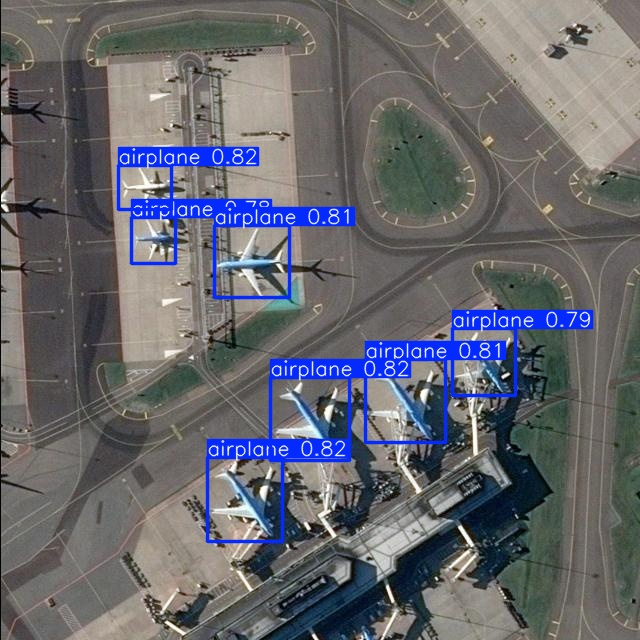

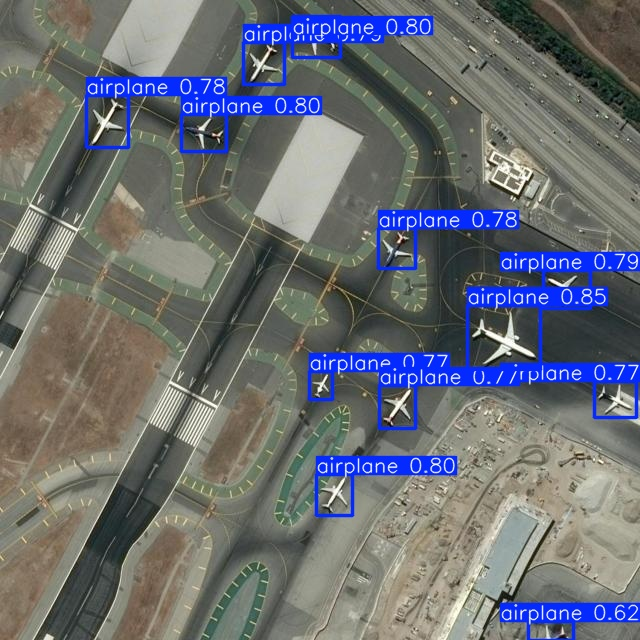

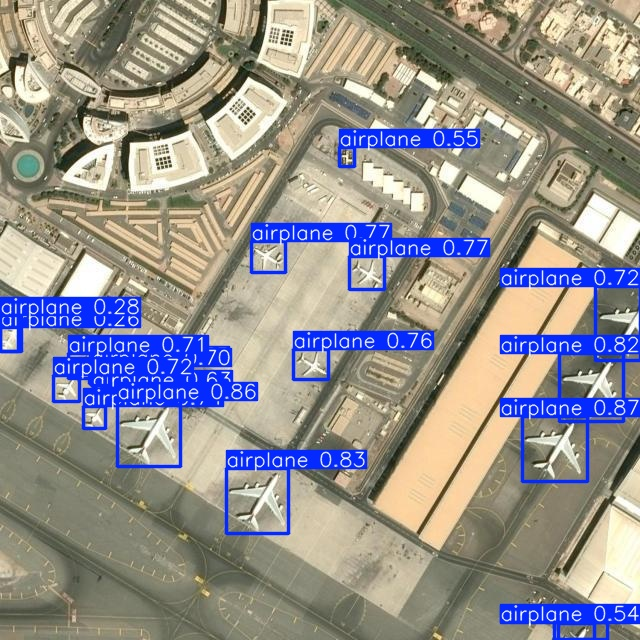

In [31]:
###### Відображаємо їх
for img_path in predicted_images:
    display(Image(filename=img_path, width=600))

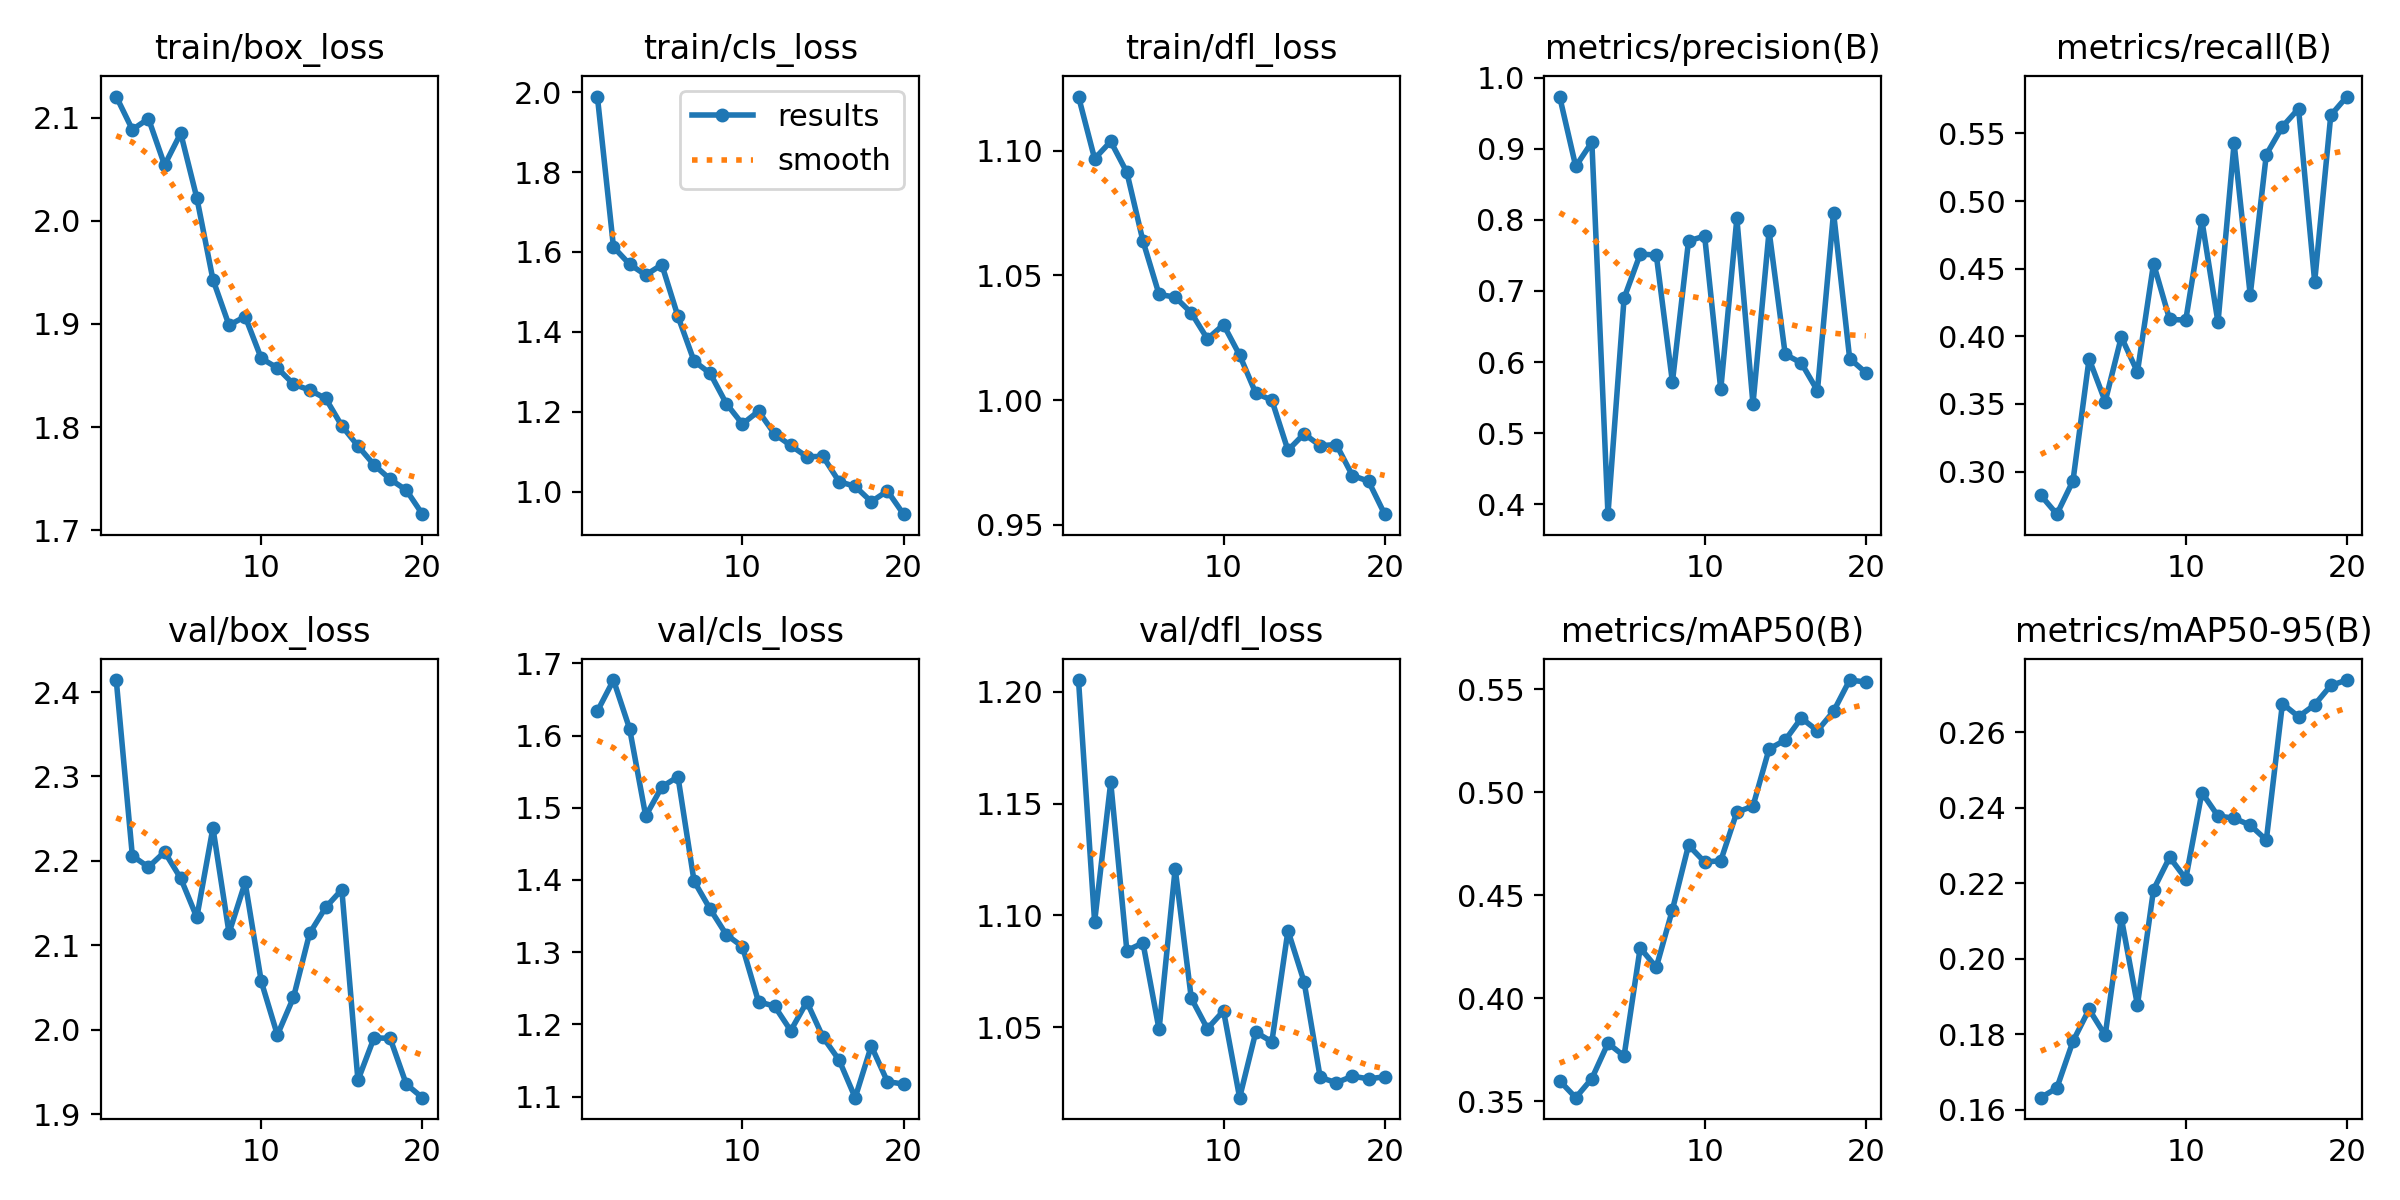

In [32]:
# from IPython.display import Image, display
# display(Image(filename='/kaggle/working/runs/detect/uav_yolo_exam-4/results.png'))